# **Linear Regression: A Gentle Introduction for Data Science Newbies**

Welcome to this beginner-friendly notebook on Linear Regression! If you're new to Data Science or Machine Learning, Linear Regression is an excellent starting point. It's a fundamental algorithm used for predicting a continuous outcome variable based on one or more input features.



## **What is Linear Regression?**

Imagine you have some data points scattered on a graph, and you want to draw a straight line that best fits these points. This line can then be used to predict new values. That's essentially what Linear Regression does!

More formally, Linear Regression is a statistical method for modeling the relationship between a dependent variable (the one we want to predict, often denoted as y) and one or more independent variables (the features we use for prediction, often denoted as x).

The simplest form, **Simple Linear Regression**, involves one independent variable and one dependent variable, and its relationship can be described by a straight line equation:

$y=mx+c$

Where:

* y: The dependent variable (what we are predicting).  
* x: The independent variable (the feature we are using).  
* m: The slope of the line (how much y changes for a unit change in x).  
* c: The y-intercept (the value of y when x is 0).

For **Multiple Linear Regression**, we have more than one independent variable:

  $y=m_1​x_1​+m_2​x_2​+⋯+m_n​x_n​+c$


## **Our Goal Today**

We will:

1. Create a simple dataset.  
2. Visualize the data to understand the relationship.  
3. Build a Simple Linear Regression model using Python's scikit-learn library.  
4. Train the model and make predictions.  
5. Evaluate how well our model performs.


## **Step 1: Importing Necessary Libraries**

First, let's import the Python libraries we'll need.

* numpy for numerical operations (especially for creating our data).  
* matplotlib.pyplot for plotting our data and the regression line.  
* sklearn.linear_model to get the LinearRegression model.  
* sklearn.model_selection to split our data.  
* sklearn.metrics to evaluate our model.


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Set a random seed for reproducibility
np.random.seed(42)

## **Step 2: Creating a Sample Dataset**

Let's imagine we're looking at the relationship between "Hours Studied" and "Exam Score". We'll generate some synthetic data that roughly follows a linear pattern.

In [ ]:
# Create a synthetic dataset
# Independent variable (Hours Studied)
X = 2 * np.random.rand(100, 1) # 100 data points between 0 and 2
# Dependent variable (Exam Score)
# We add some random noise to make it more realistic
y = 4 + 3 * X + np.random.randn(100, 1) # y = 4 + 3x + noise

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("First 5 entries of X:n", X[:5])
print("First 5 entries of y:n", y[:5])

Shape of X: (100, 1)
Shape of y: (100, 1)
First 5 entries of X:n [[0.74908024]
 [1.90142861]
 [1.46398788]
 [1.19731697]
 [0.31203728]]
First 5 entries of y:n [[6.33428778]
 [9.40527849]
 [8.48372443]
 [5.60438199]
 [4.71643995]]


## **Step 3: Visualizing the Data**

It's always a good practice to visualize your data before building a model. This helps in understanding patterns and relationships.


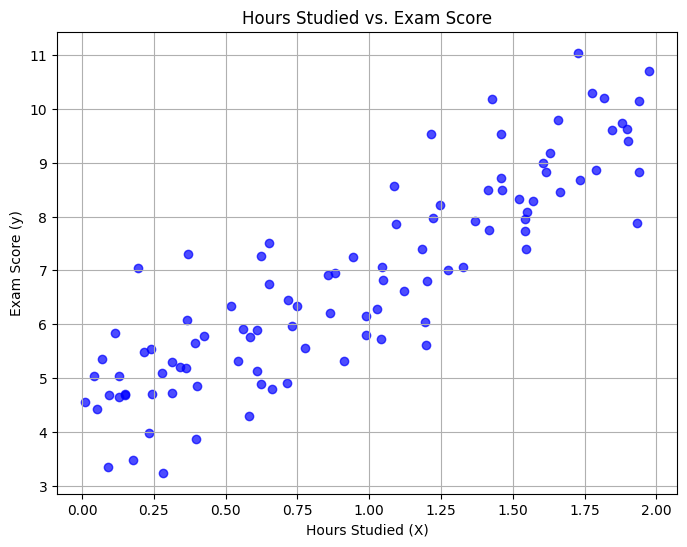

In [ ]:
# Plot the data points
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', alpha=0.7)
plt.title('Hours Studied vs. Exam Score')
plt.xlabel('Hours Studied (X)')
plt.ylabel('Exam Score (y)')
plt.grid(True)
plt.show()


From the scatter plot, you can clearly see a positive linear relationship: as hours studied increase, exam scores tend to increase.

## **Step 4: Splitting Data into Training and Testing Sets**

Before training our model, we need to split our dataset into two parts:

* **Training Set:** Used to train the model. The model learns the relationships from this data.  
* **Testing Set:** Used to evaluate the model's performance on unseen data. This helps us understand how well our model will generalize to new, real-world data.

We'll use train_test_split from sklearn.model_selection.



In [ ]:
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (80, 1)
X_test shape: (20, 1)
y_train shape: (80, 1)
y_test shape: (20, 1)


## **Step 5: Creating and Training the Linear Regression Model**

Now, let's create an instance of the LinearRegression model and train it using our training data. The fit() method is where the model learns the optimal 'm' (slope) and 'c' (intercept) values.

In [ ]:
# Create a Linear Regression model object
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

# Print the learned coefficients (slope) and intercept
print(f"Coefficient (slope): {model.coef_[0][0]:.2f}")
print(f"Intercept: {model.intercept_[0]:.2f}")

Coefficient (slope): 2.80
Intercept: 4.14


The learned slope and intercept values are very close to the 3 and 4 we used to generate the data, which is a good sign!

## **Step 6: Making Predictions**

Once the model is trained, we can use it to make predictions on new (or unseen) data. We'll use our X_test data for this.

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

print("Input hours ", X_test[:5])
print("First 5 actual test scores (y_test):n", y_test[:5])
print("nFirst 5 predicted test scores (y_pred):n", y_pred[:5])

Input hours  [[0.1271167 ]
 [1.7896547 ]
 [1.54448954]
 [1.32504457]
 [0.51755996]]
First 5 actual test scores (y_test):n [[5.03790371]
 [8.86548845]
 [7.3965179 ]
 [7.06574625]
 [6.34371184]]
nFirst 5 predicted test scores (y_pred):n [[4.49875411]
 [9.15273606]
 [8.46643942]
 [7.85214193]
 [5.59173117]]


## **Step 7: Evaluating the Model**

How good are our predictions? We need metrics to evaluate the model's performance. Two common metrics for regression tasks are:

1. **Mean Squared Error (MSE):** This measures the average of the squared differences between the actual and predicted values. Lower MSE means better fit.  
2. **R-squared (**R2**) Score:** This represents the proportion of the variance in the dependent variable that is predictable from the independent variable(s). It ranges from 0 to 1, where 1 indicates a perfect fit.


In [ ]:
# Using score() method
r2_score_using_score_method = model.score(X_test, y_test)
print(f"R-squared (R2) Score using score() method: {r2_score_using_score_method:.2f}")


R-squared (R2) Score using score() method: 0.81


In [ ]:
# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")

# Calculate R-squared (R2) score
r2 = r2_score(y_test, y_pred)
print(f"R-squared (R2) Score: {r2:.2f}")

Mean Squared Error (MSE): 0.65
R-squared (R2) Score: 0.81


An MSE of 0.65 and an R-squared score of 0.81 indicates that our model fits the data very well, explaining 81% of the variance in exam scores based on hours studied.

## **Step 8: Visualizing the Regression Line**

Let's visualize the original test data points and the regression line our model learned.

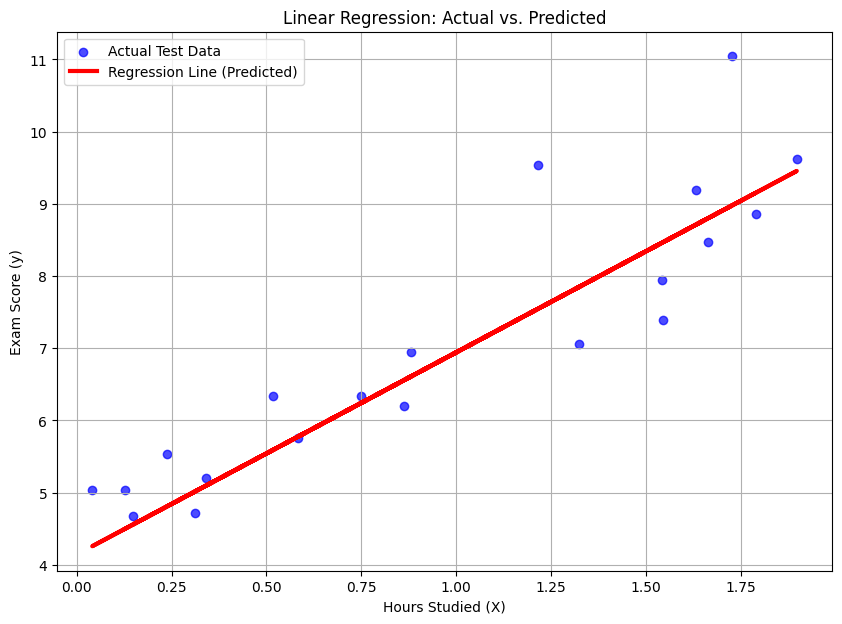

In [ ]:
# Plot the actual test data points
plt.figure(figsize=(10, 7))
plt.scatter(X_test, y_test, color='blue', alpha=0.7, label='Actual Test Data')

# Plot the regression line
plt.plot(X_test, y_pred, color='red', linewidth=3, label='Regression Line (Predicted)')

plt.title('Linear Regression: Actual vs. Predicted')
plt.xlabel('Hours Studied (X)')
plt.ylabel('Exam Score (y)')
plt.grid(True)
plt.legend()
plt.show()


The red line represents our model's prediction. You can see how it attempts to pass through the center of the data points, minimizing the distance to all points.

## **Conclusion**

Congratulations! You've just built and evaluated your first Linear Regression model. You've learned:

* The basic concept of Linear Regression and its equation.  
* How to prepare data by splitting it into training and testing sets.  
* How to train a LinearRegression model using scikit-learn.  
* How to make predictions and evaluate the model's performance using MSE and R-squared.  
* How to visualize the relationship and the regression line.

This is just the beginning! Linear Regression is a powerful and widely used algorithm.

### **Next Steps:**

* **Try different datasets:** Experiment with other simple datasets to see how the model behaves.  
* **Explore Multiple Linear Regression:** Understand how to include more than one independent variable.  
* **Learn about assumptions:** Linear Regression has certain assumptions (e.g., linearity, independence of errors). Understanding these is crucial for proper application.  
* **Dive deeper into evaluation metrics:** Learn about other metrics like MAE (Mean Absolute Error).  
* **Understand regularization:** Explore techniques like Ridge and Lasso regression to prevent overfitting.

# Visualizing Regression Fit understood by Model

n--- Visualizing Regression Line ---


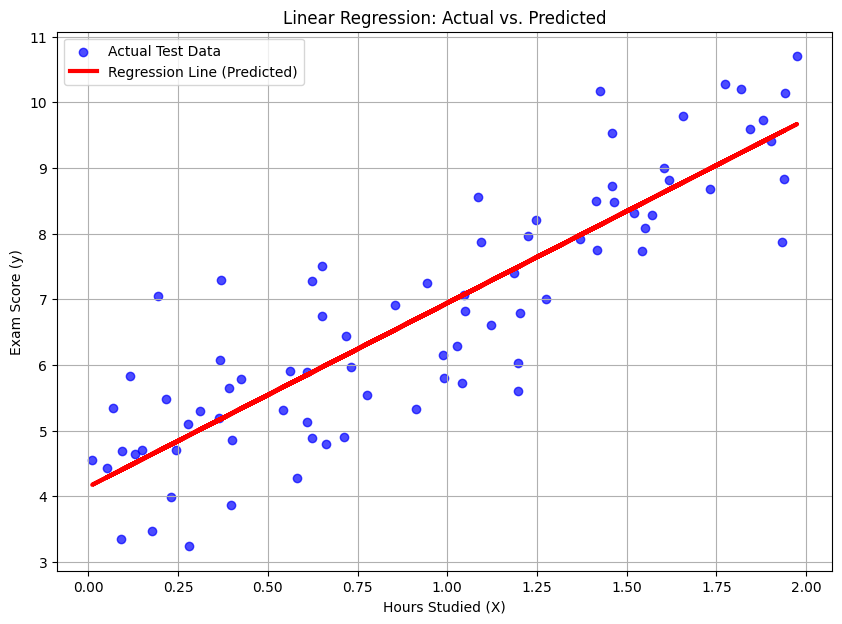

nLinear Regression example script execution complete.


In [ ]:
# Step 8: Visualizing the Regression Line
print("n--- Visualizing Regression Line ---")
plt.figure(figsize=(10, 7))
plt.scatter(X_train, y_train, color='blue', alpha=0.7, label='Actual Test Data')

# Plot the regression line
plt.plot(X_train, model.predict(X_train), color='red', linewidth=3, label='Regression Line (Predicted)')

plt.title('Linear Regression: Actual vs. Predicted')
plt.xlabel('Hours Studied (X)')
plt.ylabel('Exam Score (y)')
plt.grid(True)
plt.legend()
plt.show()

print("nLinear Regression example script execution complete.")

# Understanding Regression Slope and Intercept Fit

Epoch - 0 : m is 0.15333333333333332 and b is 0.06666666666666667
Epoch - 1 : m is 0.2896888888888889 and b is 0.12586666666666668
Epoch - 2 : m is 0.41094992592592594 and b is 0.17842844444444445
Epoch - 3 : m is 0.5187907950617284 and b is 0.22508854518518517
Epoch - 4 : m is 0.614700112381893 and b is 0.266501809145679
Epoch - 5 : m is 0.7000013628604225 and b is 0.3032504351341564
Epoch - 6 : m is 0.7758712182547501 and b is 0.33585203858372303
Epoch - 7 : m is 0.8433558230076246 and b is 0.3647668157485252
Epoch - 8 : m is 0.9033852735636386 and b is 0.3904039131799164
Epoch - 9 : m is 0.9567864915038357 and b is 0.4131270906404392
Epoch - 10 : m is 1.0042946686711933 and b is 0.4332597558341436
Epoch - 11 : m is 1.0465634426951829 and b is 0.4510894406372797
Epoch - 12 : m is 1.0841739437514746 and b is 0.4668717807833934
Epoch - 13 : m is 1.1176428377700012 and b is 0.4808340540843332
Epoch - 14 : m is 1.147429477414761 and b is 0.49317832615851315
Epoch - 15 : m is 1.1739422598

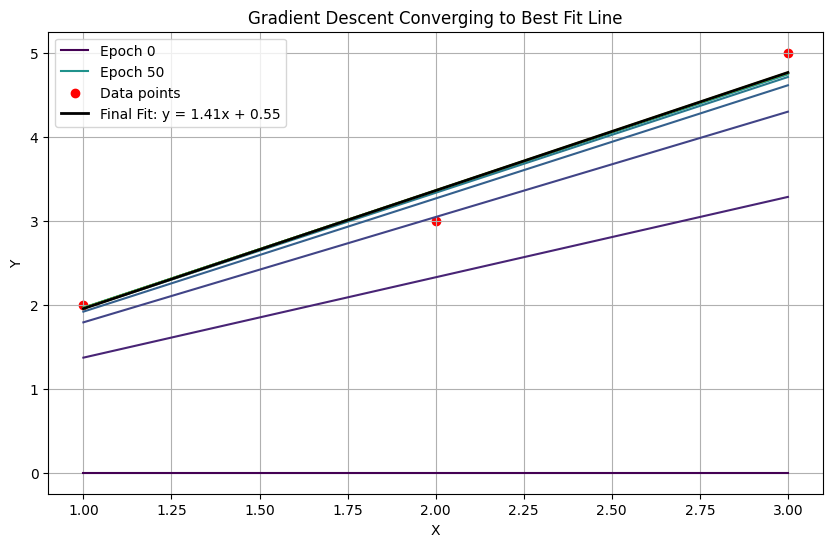

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sample dataset
X = np.array([1, 2, 3])
Y = np.array([2, 3, 5])
n = len(X)

# Learning rate and iterations
alpha = 0.01
epochs = 100

# Initialize parameters
m = 0
b = 0

# For plotting
plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, epochs))

# Gradient Descent
for i in range(epochs):
    # Predictions
    Y_pred = m * X + b

    # Compute gradients
    dm = (-2/n) * np.sum(X * (Y - Y_pred))
    db = (-2/n) * np.sum(Y - Y_pred)

    # Update parameters
    m -= alpha * dm
    b -= alpha * db

    print(f"Epoch - {i} : m is {m} and b is {b}")

    # Plot every 10th iteration
    if i % 10 == 0 or i == epochs - 1:
        label = f"Epoch {i}" if i % 50 == 0 else None
        plt.plot(X, Y_pred, color=colors[i], label=label)

# Final model
final_pred = m * X + b
plt.scatter(X, Y, color='red', label="Data points")
plt.plot(X, final_pred, color='black', linewidth=2, label=f"Final Fit: y = {m:.2f}x + {b:.2f}")

plt.title("Gradient Descent Converging to Best Fit Line")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()


# Resource

* https://www.geeksforgeeks.org/ml-linear-regression/
* https://setosa.io/ev/linear-regression/
* https://www.geeksforgeeks.org/ml-r-squared-in-regression-analysis/
* https://www.datacamp.com/tutorial/simple-linear-regression
